In [78]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns


In [36]:
df = pd.read_csv("jiji_car_dataset.csv")
df['title'] = df['title'].str.replace(r"^New\s+", "", regex=True)
df.head(472)



,title,make,model,year,condition,transmission,price
0,Mercedes-Benz GLC-Class 2018 Gray,Mercedes-Benz,GLC-Class,2018.0,local used,automatic,"₦ 17,500,000"
1,Honda Accord 2021 Black,Honda,Accord,2021.0,foreign used,automatic,"₦ 34,000,000"
2,Kia Optima EX 4dr Sedan (2.4L 4cyl 6A) 2014 Red,Kia,Optima EX,2014.0,foreign used,automatic,"₦ 13,650,000"
3,Toyota Camry 2012 White,Toyota,Camry,2012.0,local used,automatic,"₦ 9,500,000"
4,Lexus RX 2006 Gold,Lexus,RX,2006.0,local used,automatic,"₦ 7,700,000"
...,...,...,...,...,...,...,...
467,Toyota Sienna 2006 Gray,Toyota,Sienna,2006.0,foreign used,automatic,"₦ 8,200,000"
468,Toyota Highlander 2001 Black,Toyota,Highlander,2001.0,local used,automatic,"₦ 4,900,000"
469,Mazda CX-9 2009 Blue,Mazda,CX-9,2009.0,local used,automatic,"₦ 5,500,000"
470,Rolls-Royce Cullinan 2024 Black,New,Rolls-Royce Cullinan,2024.0,brand new,automatic,"₦ 1,590,000,000"


In [39]:
def extract_make_model_year(title):
    clean_title = re.sub(r"^New\s+", "", title, flags=re.IGNORECASE)
    pattern = r"(?P<Make>\b[a-zA-z\-]+)\s+(?P<Model>[A-Za-z0-9\-]+(?:\s[A-za-z0-9\-]+)?)?.*?(?P<Year>\d{4})(?!\d)"
    match = re.search(pattern,title)
    if match:
        return match.group("Make"), match.group("Model"), match.group("Year")
    return None, None, None

In [40]:
df[['Make', 'Model', 'Year']] = df['title'].apply(
    lambda x: pd.Series(extract_make_model_year(x))
)



In [41]:
df.shape

(2000, 10)

In [42]:
df.columns

Index(['title', 'make', 'model', 'year', 'condition', 'transmission', 'price',
       'Make', 'Model', 'Year'],
      dtype='str')

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         2000 non-null   str    
 1   make          1993 non-null   str    
 2   model         1992 non-null   str    
 3   year          1993 non-null   float64
 4   condition     2000 non-null   str    
 5   transmission  1996 non-null   str    
 6   price         2000 non-null   str    
 7   Make          1993 non-null   str    
 8   Model         1992 non-null   str    
 9   Year          1993 non-null   str    
dtypes: float64(1), str(9)
memory usage: 350.9 KB


In [44]:
df.describe(include="all")

,title,make,model,year,condition,transmission,price,Make,Model,Year
count,2000,1993,1992,1993.000000,2000,1996,2000,1993,1992,1993
unique,1751,44,454,NaN,3,2,623,47,439,35
top,Toyota Hilux 2025 Black,Toyota,Camry,NaN,foreign used,automatic,"₦ 13,500,000",Toyota,Camry,2016
freq,6,747,91,NaN,1075,1932,24,787,93,145
mean,NaN,NaN,NaN,2013.774711,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,6.360088,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,1958.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,2009.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,2014.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
df.isnull().sum()

title           0
make            7
model           8
year            7
condition       0
transmission    4
price           0
Make            7
Model           8
Year            7
dtype: int64

In [46]:
df[df['make'].isna() & df["model"].isna()]

,title,make,model,year,condition,transmission,price,Make,Model,Year
202,Mercedes-Benz GL-Class GL450 4MATIC 4dr SUV AW...,NaN,NaN,NaN,local used,automatic,"₦ 20,000,000",NaN,NaN,NaN
493,Toyota Tacoma TRD PRO V6 4dr Access Cab 4WD 6....,NaN,NaN,NaN,foreign used,automatic,"₦ 24,000,000",NaN,NaN,NaN
546,Mercedes-Benz GL-Class GL450 4MATIC 4dr SUV AW...,NaN,NaN,NaN,foreign used,automatic,"₦ 30,500,000",NaN,NaN,NaN
1048,Mercedes-Benz M Class ML400 4MATIC 4dr SUV AWD...,NaN,NaN,NaN,foreign used,automatic,"₦ 30,000,000",NaN,NaN,NaN
1133,Mercedes-Benz M Class ML400 4MATIC 4dr SUV AWD...,NaN,NaN,NaN,foreign used,automatic,"₦ 33,500,000",NaN,NaN,NaN
1854,Hyundai Sonata Limited w/Brown Leather PZEV 4d...,NaN,NaN,NaN,foreign used,automatic,"₦ 16,000,000",NaN,NaN,NaN
1943,Mercedes-Benz M Class ML400 4MATIC 4dr SUV AWD...,NaN,NaN,NaN,foreign used,automatic,"₦ 22,800,000",NaN,NaN,NaN


In [47]:
#dropping nan data 
df= df.dropna()
df.shape

(1988, 10)

In [48]:
#clean the price column

df['price'] = (
    df['price'].astype(str).str.replace("₦", "", regex=False).str.replace(",", "", regex=False).str.strip()
)

df['price'] = pd.to_numeric(df['price'], errors='coerce')



In [49]:
df['price'].describe()

count    1.988000e+03
mean     4.311720e+07
std      9.800192e+07
min      1.700000e+06
25%      7.850000e+06
50%      1.650000e+07
75%      3.600000e+07
max      1.600000e+09
Name: price, dtype: float64

In [50]:
df['price'].head(10)

0    17500000
1    34000000
2    13650000
3     9500000
4     7700000
5     5900000
6     2200000
7     9000000
8     8226562
9    37000000
Name: price, dtype: int64

In [51]:
df = df[df['price'] > 0]

In [52]:
#Cars with the highest price
df.nlargest(10, "price")[['title','Make', 'Model', 'Year', 'price']]

,title,Make,Model,Year,price
814,Lamborghini Urus 2025 Black,Lamborghini,Urus,2025,1600000000
470,Rolls-Royce Cullinan 2024 Black,Rolls-Royce,Cullinan,2024,1590000000
641,Rolls-Royce Cullinan Black Badge 2024 Black,Rolls-Royce,Cullinan Black,2024,1500000000
1185,Mercedes-Benz G-Class 2025 Black,Mercedes-Benz,G-Class,2025,870000000
816,Land Rover Range Rover Vogue 2025 Black,Land,Rover Range,2025,770000000
619,Rolls-Royce Cullinan Base 2021 White,Rolls-Royce,Cullinan Base,2021,760000000
534,Rolls-Royce Cullinan 2022 White,Rolls-Royce,Cullinan,2022,699999999
882,Mercedes-Benz G-Class G63 AMG Brabus G700 2024...,Mercedes-Benz,G-Class G63,2024,650000000
726,Rolls-Royce Cullinan Base 2019 Black,Rolls-Royce,Cullinan Base,2019,610000000
412,Rolls-Royce Cullinan Base 2020 White,Rolls-Royce,Cullinan Base,2020,590000000


In [53]:
# standardized the categorical column
categorical_cols = ["Make", "Model", "condition", "transmission"]

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()


In [54]:
df.head()

,title,make,model,year,condition,transmission,price,Make,Model,Year
0,Mercedes-Benz GLC-Class 2018 Gray,Mercedes-Benz,GLC-Class,2018.0,local used,automatic,17500000,Mercedes-Benz,GLC-Class,2018
1,Honda Accord 2021 Black,Honda,Accord,2021.0,foreign used,automatic,34000000,Honda,Accord,2021
2,Kia Optima EX 4dr Sedan (2.4L 4cyl 6A) 2014 Red,Kia,Optima EX,2014.0,foreign used,automatic,13650000,Kia,Optima EX,2014
3,Toyota Camry 2012 White,Toyota,Camry,2012.0,local used,automatic,9500000,Toyota,Camry,2012
4,Lexus RX 2006 Gold,Lexus,RX,2006.0,local used,automatic,7700000,Lexus,RX,2006


In [55]:
# dropping the old make, model and year
df = df.drop(columns=['make','model','year'])

In [56]:
df.head()

,title,condition,transmission,price,Make,Model,Year
0,Mercedes-Benz GLC-Class 2018 Gray,local used,automatic,17500000,Mercedes-Benz,GLC-Class,2018
1,Honda Accord 2021 Black,foreign used,automatic,34000000,Honda,Accord,2021
2,Kia Optima EX 4dr Sedan (2.4L 4cyl 6A) 2014 Red,foreign used,automatic,13650000,Kia,Optima EX,2014
3,Toyota Camry 2012 White,local used,automatic,9500000,Toyota,Camry,2012
4,Lexus RX 2006 Gold,local used,automatic,7700000,Lexus,RX,2006


In [57]:
df = df.rename(columns={
    'title': "Title",
    'condition': 'Condition',
    'transmission': 'Transmission',
    'price': 'Price'
})

df.head()

,Title,Condition,Transmission,Price,Make,Model,Year
0,Mercedes-Benz GLC-Class 2018 Gray,local used,automatic,17500000,Mercedes-Benz,GLC-Class,2018
1,Honda Accord 2021 Black,foreign used,automatic,34000000,Honda,Accord,2021
2,Kia Optima EX 4dr Sedan (2.4L 4cyl 6A) 2014 Red,foreign used,automatic,13650000,Kia,Optima EX,2014
3,Toyota Camry 2012 White,local used,automatic,9500000,Toyota,Camry,2012
4,Lexus RX 2006 Gold,local used,automatic,7700000,Lexus,RX,2006


In [59]:
df["Condition"] = df['Condition'].str.title()
df['Transmission'] = df['Transmission'].str.title()

df.head()

,Title,Condition,Transmission,Price,Make,Model,Year
0,Mercedes-Benz GLC-Class 2018 Gray,Local Used,Automatic,17500000,Mercedes-Benz,GLC-Class,2018
1,Honda Accord 2021 Black,Foreign Used,Automatic,34000000,Honda,Accord,2021
2,Kia Optima EX 4dr Sedan (2.4L 4cyl 6A) 2014 Red,Foreign Used,Automatic,13650000,Kia,Optima EX,2014
3,Toyota Camry 2012 White,Local Used,Automatic,9500000,Toyota,Camry,2012
4,Lexus RX 2006 Gold,Local Used,Automatic,7700000,Lexus,RX,2006


In [60]:
df.to_csv("New_clean_jiji_automobile.csv", index=False)

In [61]:
df['Make'].value_counts()

Make
Toyota           785
Mercedes-Benz    339
Lexus            277
Honda            134
Hyundai          104
Ford              57
Nissan            34
BMW               32
Land              30
Acura             23
Volkswagen        19
Kia               18
Mazda             10
Rolls-Royce       10
Peugeot           10
Dodge              9
Jeep               9
Mitsubishi         8
Infiniti           7
Pontiac            7
Jetour             7
Cadillac           6
Audi               6
BYD                5
Chevrolet          5
Rover              4
Suzuki             3
Volvo              3
Lamborghini        3
GAC                2
Mini               2
Opel               2
JMC                2
Geely              2
Porsche            2
Denza              2
Tesla              1
Ferrari            1
ZX                 1
Changan            1
GMC                1
Zeekr              1
Hummer             1
IVM                1
Daihatsu           1
JAC                1
Name: count, dtype: int64

In [62]:
df['Year'].describe()

count     1988
unique      35
top       2016
freq       144
Name: Year, dtype: object

In [63]:
df['Year'] = pd.to_numeric(df['Year'])
df = df[(df['Year'] >= 1980) & (df['Year'] < 2025)]

In [65]:
df['Year']

0       2018
1       2021
2       2014
3       2012
4       2006
        ... 
1995    2022
1996    2015
1997    2010
1998    2019
1999    2016
Name: Year, Length: 1891, dtype: int64

## NOW EDA

In [66]:
# Most common car brand
make_counts = df['Make'].value_counts()
make_counts.head(10)

Make
Toyota           747
Mercedes-Benz    321
Lexus            264
Honda            131
Hyundai          103
Ford              57
Nissan            33
BMW               32
Land              27
Acura             23
Name: count, dtype: int64

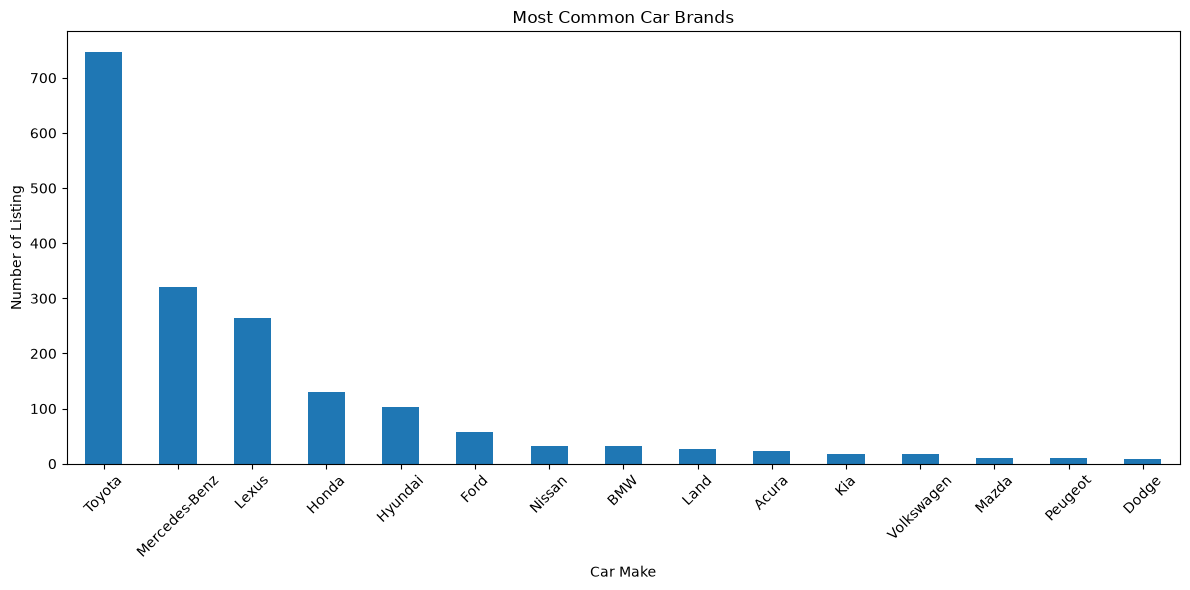

In [69]:
# Bar chart
plt.figure(figsize=(12,6))

make_counts.head(15).plot(kind="bar")

plt.title("Most Common Car Brands")
plt.xlabel("Car Make")
plt.ylabel("Number of Listing")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [70]:
# Most common model per brand
df["Model"].value_counts().head(15)

Model
Camry            90
Corolla          68
RX               62
RX 350           57
Land Cruiser     54
Highlander       49
GLE-Class GLE    42
Accord           36
Hilux            35
Camry LE         32
GLC-Class        31
Camry SE         31
Sienna           30
ES 350           28
Santa Fe         28
Name: count, dtype: int64

In [71]:
popular_models = (
    df.groupby(["Make", "Model"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

popular_models.head(20)

,Make,Model,count
320,Toyota,Camry,90
329,Toyota,Corolla,68
188,Lexus,RX,62
191,Lexus,RX 350,57
362,Toyota,Land Cruiser,54
347,Toyota,Highlander,49
243,Mercedes-Benz,GLE-Class GLE,42
85,Honda,Accord,36
357,Toyota,Hilux,35
323,Toyota,Camry LE,32


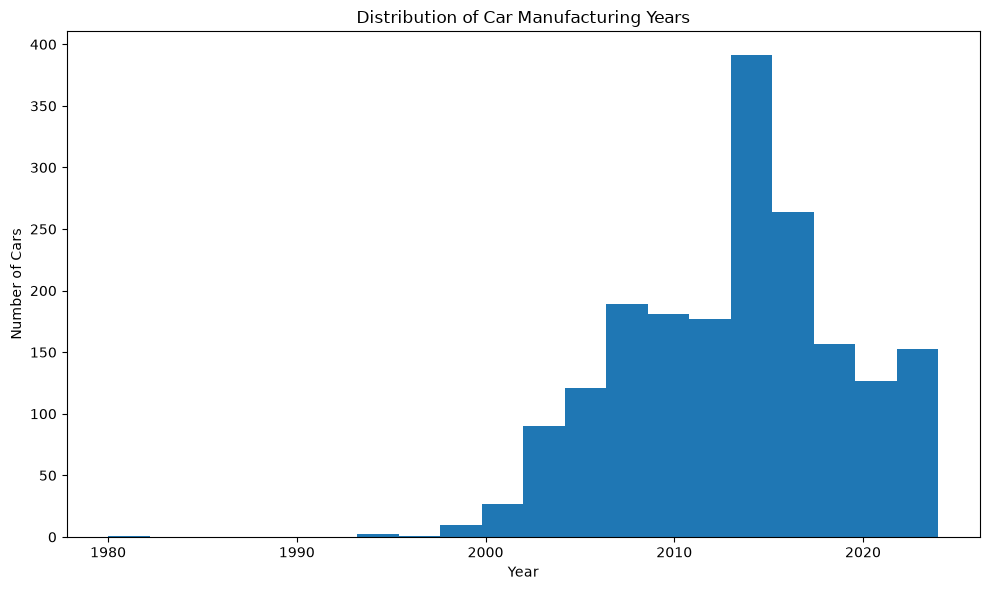

In [72]:
plt.figure(figsize=(10, 6))

plt.hist(df["Year"], bins=20)

plt.title("Distribution of Car Manufacturing Years")
plt.xlabel("Year")
plt.ylabel("Number of Cars")

plt.tight_layout()
plt.show()

In [74]:
# Average price per brands
avg_price_make = (
    df.groupby("Make")["Price"]
    .mean()
    .sort_values(ascending=False)
)

avg_price_make.head(15)

Make
Rolls-Royce      7.772222e+08
Tesla            3.450000e+08
Lamborghini      3.100000e+08
Cadillac         1.018000e+08
Land             9.317125e+07
Geely            6.250000e+07
Mercedes-Benz    5.608983e+07
Chevrolet        5.276800e+07
BMW              4.647539e+07
Jetour           4.400000e+07
Audi             3.979167e+07
Jeep             3.930677e+07
Lexus            3.835702e+07
Changan          3.600000e+07
BYD              3.550000e+07
Name: Price, dtype: float64

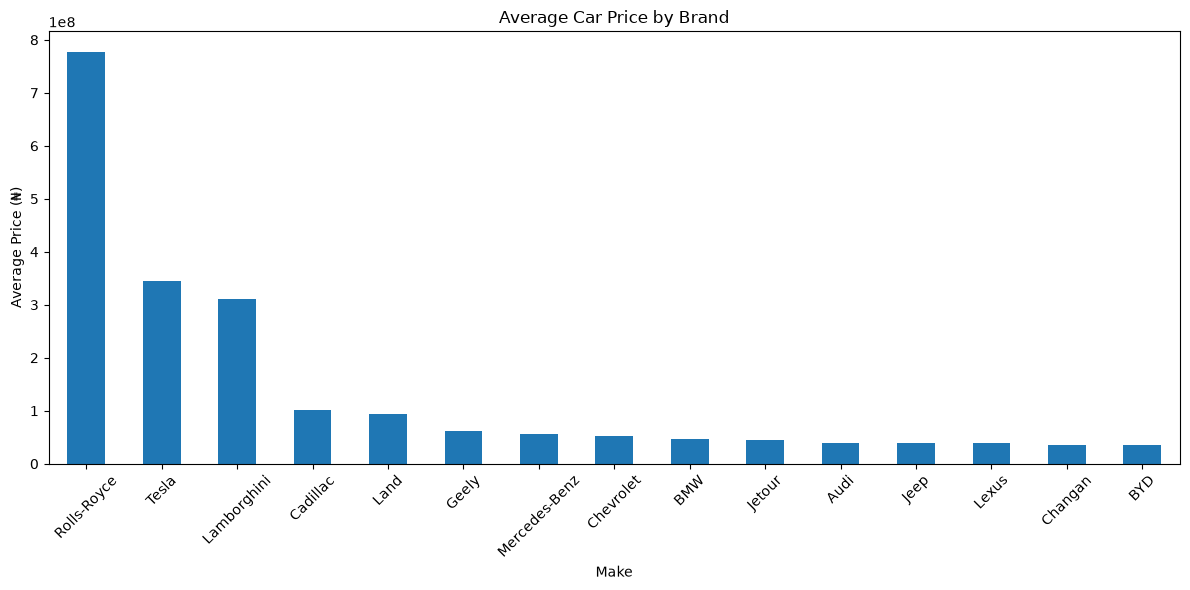

In [75]:
plt.figure(figsize=(12, 6))

avg_price_make.head(15).plot(kind="bar")

plt.title("Average Car Price by Brand")
plt.xlabel("Make")
plt.ylabel("Average Price (₦)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [76]:
# median make
avg_price_model = (
    df.groupby(["Make", "Model"])["Price"]
    .agg(["mean", "median", "count"])
    .sort_values("mean", ascending=False)
)

avg_price_model.head(20)


mean        median  count
Make          Model                                            
Rolls-Royce   Cullinan Black  1.500000e+09  1.500000e+09      1
              Cullinan        1.145000e+09  1.145000e+09      2
              Cullinan Base   6.533333e+08  6.100000e+08      3
Lexus         LX LX           5.500000e+08  5.500000e+08      1
Rolls-Royce   Phantom Base    5.400000e+08  5.400000e+08      1
Mercedes-Benz SL-Class AMG    4.600000e+08  4.600000e+08      1
Rolls-Royce   Ghost Standard  3.850000e+08  3.850000e+08      1
Mercedes-Benz G-Class G63     3.565000e+08  3.565000e+08      2
Tesla         Cybertruck      3.450000e+08  3.450000e+08      1
Lamborghini   Urus            3.400000e+08  3.400000e+08      1
Mercedes-Benz Brabus G        3.350000e+08  3.350000e+08      1
Rolls-Royce   Wraith 6        3.200000e+08  3.200000e+08      1
BMW           7 Series        2.950000e+08  2.950000e+08      2
Lamborghini   Urus Base       2.800000e+08  2.800000e+08      1
Mercedes-Benz G-Class G       2.668750e+08  2.420000e+08      8
Lexus         LX 600          2.350000e+08  2.350000e+08      1
Mercedes-Benz G-Class         2.226250e+08  1.832500e+08      4
Lexus         LX              2.056818e+08  1.190000e+08     11
Mercedes-Benz GLS-Class       1.990000e+08  1.990000e+08      1
              GLC-Class AMG   1.950000e+08  1.950000e+08      1

In [77]:
# condition vs price
df.groupby("Condition")["Price"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
Condition,,,
Brand New,25,3.139680e+08,155000000.0
Foreign Used,1037,4.158741e+07,22000000.0
Local Used,829,1.717377e+07,6900000.0


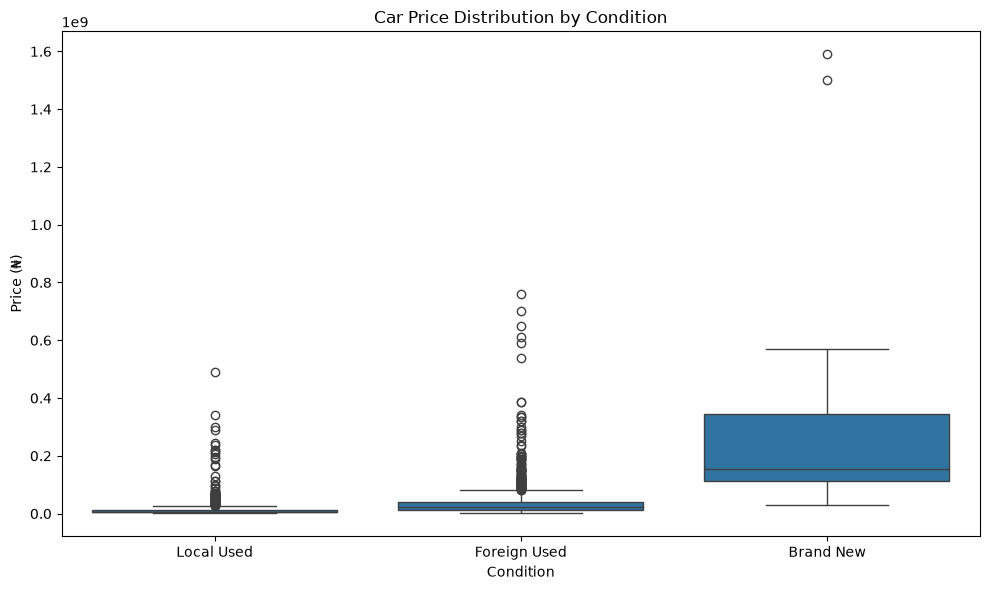

In [80]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Condition",
    y="Price"
)

plt.title("Car Price Distribution by Condition")
plt.xlabel("Condition")
plt.ylabel("Price (₦)")

plt.tight_layout()
plt.show()

In [81]:
# Transmission vs price
df.groupby("Transmission")["Price"].agg(
    ["count", "mean", "median"]
)

,count,mean,median
Transmission,,,
Automatic,1830,3.517064e+07,15760156.0
Manual,61,1.393667e+07,4900000.0


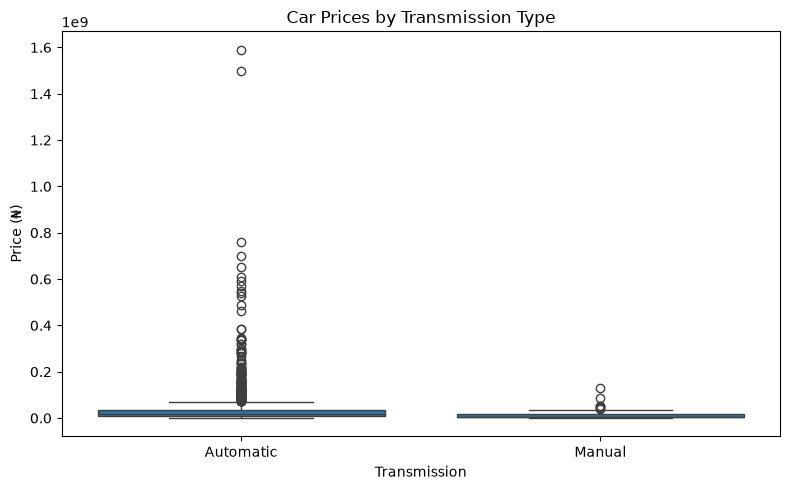

In [82]:
# chart to visualize transmission and price 
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Transmission",
    y="Price"
)

plt.title("Car Prices by Transmission Type")
plt.xlabel("Transmission")
plt.ylabel("Price (₦)")

plt.tight_layout()
plt.show()

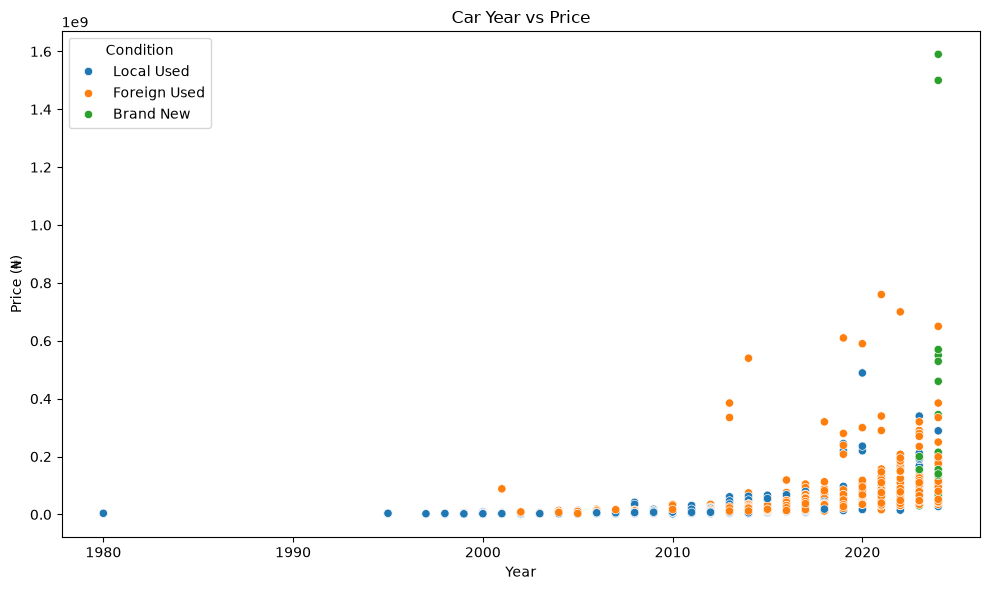

In [83]:
#Year vs price 
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Year",
    y="Price",
    hue="Condition"
)

plt.title("Car Year vs Price")
plt.xlabel("Year")
plt.ylabel("Price (₦)")

plt.tight_layout()
plt.show()

In [84]:
correlation = df["Year"].corr(df["Price"])

print("Correlation between year and price:", correlation)

Correlation between year and price: 0.41763648836520656


In [86]:
# correlation heat map
numeric_cols = ["Year", "Price"]

correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,Year,Price
Year,1.000000,0.417636
Price,0.417636,1.000000


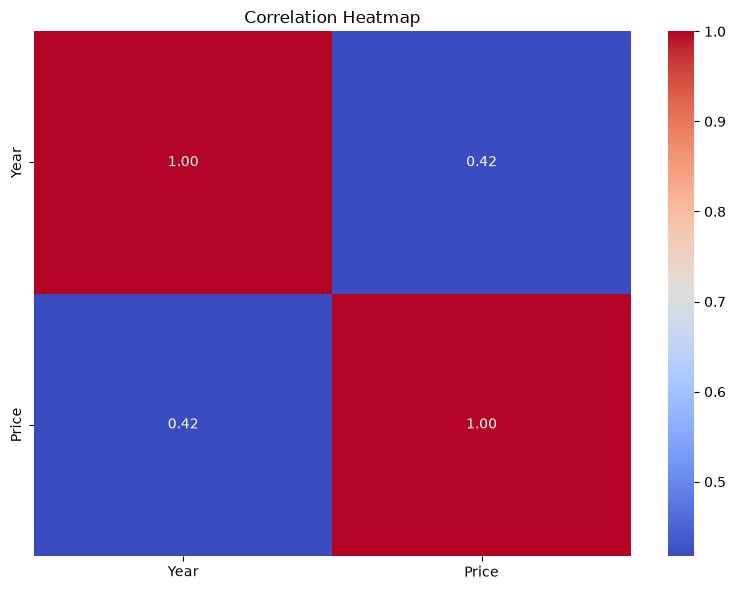

In [87]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

## Summary of Findings

- **Which brands cost the most?** Rolls-Royce and Land Rover show the highest average prices, but very few of them were listed (under 30 cars each), so we can't trust that number — too small a sample to mean anything solid. Among brands with enough listings to trust the numbers, Mercedes-Benz (₦69.9M average, 339 cars) and Lexus (₦49.5M average, 277 cars) are the real price leaders. Toyota's average price is lower (₦29M), but it has way more listings than any other brand (785 cars) — so Toyota isn't the most expensive, it's just the most common/most sold.

- **Foreign Used vs Local Used — which costs more?** Foreign Used cars average ₦43.8M, Local Used average ₦17.3M. That's about 2.5x more expensive for Foreign Used. Brand New cars average ₦273M but there were only 90 of them listed, so that number can swing easily and isn't very reliable — small sample.

- **Does the car's year affect price?** Yes, but not perfectly. We measured this with a correlation score of 0.44 (correlation just means: how strongly two things move together, on a scale of 0 to 1 — 0.44 is a "moderate" relationship, not super strong). When we grouped cars into 5-year chunks though, the pattern is very clear: cars from 2000–2004 average ₦5M, 2010–2014 average ₦17M, 2015–2019 average ₦34M, and 2020–2024 average ₦121M. So older cars really do lose value, step by step.

- **Automatic vs Manual.** Almost all the cars for sale are automatic — 1,924 out of 1,988 total (that's 97%). Automatic cars also cost more on average (₦44M) compared to manual (₦16.1M). Manual cars are rare and mostly cheaper, older cars.

- **Which model holds its value best — Hilux, RX 350, or Accord?** Toyota Hilux wins — average price ₦72.2M, and the cars are fairly recent (average year 2019.6). Lexus RX 350 comes next — ₦39.9M average, slightly older cars on average (2014.9). Honda Accord is lowest — ₦8.7M average, and also the oldest of the three (2010.5). So Accord loses value the most over time; Hilux keeps its value the best.

## Business Insights & Recommendations

- **Best-selling brand/model overall:** Toyota is the most popular brand by far (most cars listed = most in-demand). If you're picking one specific model that performs best, it's the Toyota Hilux — it sells for a high price even as a used car.

- **Which category brings in the most money:** Foreign Used cars. They have more listings than Local Used (1,066 vs 832) AND cost more per car — so together, they bring in more total money to the market than Local Used cars do.

- **When were most cars made:** Most of the cars listed were made between 2015–2019 (558 cars), closely followed by 2010–2014 (555 cars). Newer cars (2020 and later) are fewer in number, but they sell for the highest prices.

- **What to do about the weaker segments (Local Used, Manual cars):**
  1. Local Used cars sell in high numbers but at low prices — instead of competing on cheap price, add things like a warranty or a proper inspection to make them worth more.
  2. Manual cars are now a tiny part of the market (only 3%) — it may not be worth spending much effort sourcing more of them.
  3. Focus on getting more automatic, Foreign Used cars from 2015 onward — this is the combination that's already proven to sell for the most.